# Data Visualization - Part II
By the end of this session, students will be able to:
- Translate business questions into visual analysis tasks
- Understand data distributions, quality issues, and structure before plotting
- Create core visualizations (distribution, comparison, relationship, trend) using Python
- Select appropriate visualization types based on analytical goals

In [ ]:
# Import core libraries for data analysis and visualization
import pandas as pd              # Data manipulation and analysis
import numpy as np               # Numerical operations
import matplotlib.pyplot as plt  # Basic plotting
import seaborn as sns            # Advanced statistical visualization

from pathlib import Path         # For handling file paths (more robust than raw strings)

# -----------------------------
# Display Settings (Pandas)
# -----------------------------

# Show up to 50 columns when displaying a DataFrame
pd.set_option("display.max_columns", 50)

# Format floating-point numbers to 2 decimal places with commas (e.g., 1,234.56)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# -----------------------------
# Visualization Settings
# -----------------------------

# Set a clean, grid-based theme for seaborn plots
sns.set_theme(style="whitegrid")

# Set default figure size for all matplotlib plots
plt.rcParams["figure.figsize"] = (10, 6)

# -----------------------------
# Load Dataset
# -----------------------------

# Read CSV file into a pandas DataFrame
# - "retail_visualization_dataset.csv" is the data source
# - parse_dates converts the "order_date" column into datetime format
#   (important for time-based analysis later)
df = pd.read_csv("retail_visualization_dataset.csv", parse_dates=["order_date"])

# -----------------------------
# Initial Data Inspection
# -----------------------------

# Print the shape of the dataset: (rows, columns)
# Helps understand dataset size and dimensionality
print("Shape:", df.shape)

# Display the first 2 rows of the dataset
# Quick sanity check to understand structure and column types
df.head(2)

: 

## Why visualization matters

In real analytics work, visualization is usually not the end goal.  
The end goal is to support a decision.

A useful way to think about visualization is:

> **Question → Data → Visual → Insight → Action**

### Examples
- **Question:** Which region is underperforming?
- **Visual:** A bar chart comparing profit by region
- **Insight:** Central has the lowest profit and high discount levels
- **Action:** Review discount strategy and shipping mix in Central

### A strong analyst does not start with:
> “Which plot should I make?”

A strong analyst starts with:
> “What am I trying to learn from the data?”

### Quick thinking exercise

Before touching code, write down at least 5 business questions this dataset might help answer.

Examples:
- Which categories generate the most sales?
- Which categories generate the most profit?
- Do discounts appear to hurt profitability?
- Are some shipping modes associated with lower profit?
- Does performance change over time?

Write your own questions below.

In [3]:
# Write your questions here as comments or strings.
questions = [
    "1.",
    "2.",
    "3.",
    "4.",
    "5."
]
questions

['1.', '2.', '3.', '4.', '5.']

## Meet the dataset

Let's inspect the structure before plotting anything.

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6014 entries, 0 to 6013
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      6014 non-null   str           
 1   order_date    6014 non-null   datetime64[us]
 2   region        6014 non-null   str           
 3   state         6014 non-null   str           
 4   segment       6014 non-null   str           
 5   category      6014 non-null   str           
 6   sub_category  6014 non-null   str           
 7   ship_mode     6002 non-null   str           
 8   quantity      6014 non-null   int64         
 9   discount      5996 non-null   float64       
 10  sales         6014 non-null   float64       
 11  profit        5996 non-null   float64       
 12  customer_id   6014 non-null   str           
dtypes: datetime64[us](1), float64(3), int64(1), str(8)
memory usage: 610.9 KB


In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
order_id,6014,6014,ORD-2024-00000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_date,6014,NaN,NaN,NaN,2025-01-01 18:42:15.683405,2024-01-01 00:00:00,2024-07-03 00:00:00,2025-01-03 00:00:00,2025-07-06 18:00:00,2025-12-30 00:00:00,NaN
region,6014,4,West,1725,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,6014,16,California,445,NaN,NaN,NaN,NaN,NaN,NaN,NaN
segment,6014,3,Consumer,3128,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,6014,3,Office Supplies,2501,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sub_category,6014,12,Binders,648,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ship_mode,6002,4,Standard Class,3512,NaN,NaN,NaN,NaN,NaN,NaN,NaN
quantity,"6,014.00",NaN,NaN,NaN,4.46,1.00,2.00,4.00,6.00,10.00,2.28
discount,"5,996.00",NaN,NaN,NaN,0.14,0.00,0.07,0.12,0.19,0.55,0.09


### Dataset columns

- **order_id**: unique order identifier  
- **order_date**: date of the order  
- **region / state**: geographic fields  
- **segment**: customer segment  
- **category / sub_category**: product hierarchy  
- **ship_mode**: shipping method  
- **quantity**: number of units  
- **discount**: discount rate applied  
- **sales**: revenue  
- **profit**: profit after estimated costs  
- **customer_id**: customer identifier

### Important reminder
Before plotting, always ask:
1. Which variables are numeric?
2. Which are categorical?
3. Which are time variables?
4. Are there missing values or odd values?
5. Are there outliers that may dominate the visual?

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include="object").columns.tolist()
datetime_cols = df.select_dtypes(include="datetime").columns.tolist()

print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)
print("Datetime:", datetime_cols)

Numeric: ['quantity', 'discount', 'sales', 'profit']
Categorical: ['order_id', 'region', 'state', 'segment', 'category', 'sub_category', 'ship_mode', 'customer_id']
Datetime: ['order_date']


C:\Users\hlu\AppData\Local\Temp\ipykernel_7252\2429398746.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns.tolist()


## Visualization basics in Python

In this course, code is a tool, not the main goal.  
Because AI can help generate syntax, your job is to understand:
- what kind of chart to use,
- what to put on each axis,
- and how to interpret the result.

We will use two core libraries:

- **Matplotlib**: lower-level control
- **Seaborn**: faster, cleaner statistical graphics

### A first chart with Matplotlib

In [ ]:
df["order_date"].dt.to_period("M")

0       2024-04
1       2025-03
2       2024-09
3       2024-04
4       2024-03
         ...   
6009    2025-08
6010    2025-08
6011    2025-08
6012    2025-08
6013    2025-08
Name: order_date, Length: 6014, dtype: period[M]

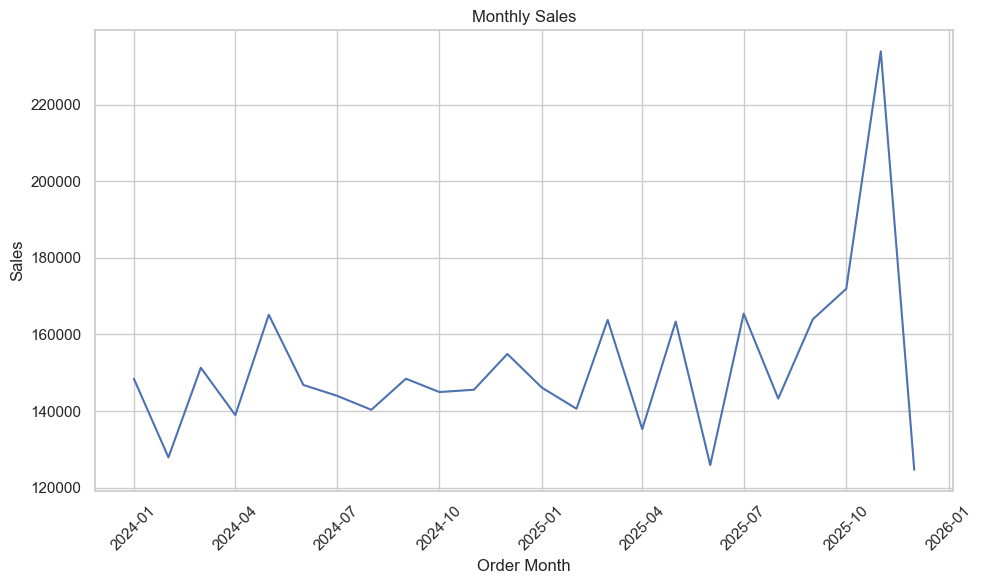

In [ ]:
import matplotlib.pyplot as plt

# -----------------------------
# Data Preparation: Monthly Sales
# -----------------------------

# Create a new DataFrame that aggregates total sales by month
monthly_sales = (
    df
    # Create a new column "order_month"
    # - Convert order_date to monthly period (e.g., 2024-01)
    # - Then convert back to timestamp (e.g., 2024-01-01)
    # This ensures all dates in the same month align to a single value
    .assign(order_month=df["order_date"].dt.to_period("M").dt.to_timestamp())
    
    # Group data by the new "order_month" column
    # as_index=False keeps "order_month" as a regular column (not index)
    .groupby("order_month", as_index=False)["sales"]
    
    # Sum sales for each month
    .sum()
)

# -----------------------------
# Visualization: Line Plot
# -----------------------------

# Plot monthly sales trend
# - x-axis: month
# - y-axis: total sales
plt.plot(monthly_sales["order_month"], monthly_sales["sales"])

# Add chart title
plt.title("Monthly Sales")

# Label x-axis
plt.xlabel("Order Month")

# Label y-axis
plt.ylabel("Sales")

# Rotate x-axis labels for better readability (dates can overlap)
plt.xticks(rotation=45)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Display the plot
plt.show()

### Why this chart works
A line chart works well because the question is about **trend over time**.

When your question is:
- “What changed over time?”
- “Is performance going up or down?”
- “Are there seasonal patterns?”

a line chart is often a good first choice.

### A first chart with Seaborn

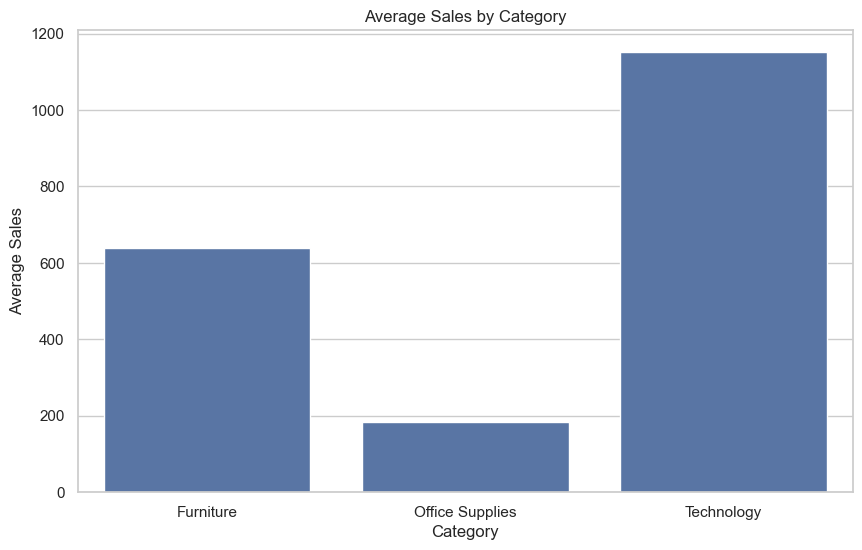

In [ ]:
import seaborn as sns

# -----------------------------
# Visualization: Average Sales by Category (Bar Plot)
# -----------------------------

# Create a bar plot using seaborn
sns.barplot(
    data=df,
    
    # x-axis: categorical variable (product category)
    x="category",
    
    # y-axis: numerical variable (sales)
    y="sales",
    
    # estimator defines how values are aggregated within each category
    # "mean" means we compute the average sales per category
    estimator="mean",
    
    # errorbar=None removes confidence interval bars (keeps chart simple)
    # by default, seaborn shows uncertainty (e.g., 95% CI)
    errorbar=None
)

# Add chart title
plt.title("Average Sales by Category")

# Label x-axis
plt.xlabel("Category")

# Label y-axis
plt.ylabel("Average Sales")

# Display the plot
plt.show()

### Why this chart works
A bar chart works well because the question is about **comparison across groups**.

When your question is:
- “Which group performs better?”
- “How do categories compare?”
- “Which region has the highest average profit?”

bar charts are often useful.

### Basic syntax patterns you should know

You do **not** need to memorize everything, but you should understand these recurring patterns:
- `data=...`
- `x=...`
- `y=...`
- `hue=...` for an extra grouping variable
- titles and labels for clarity

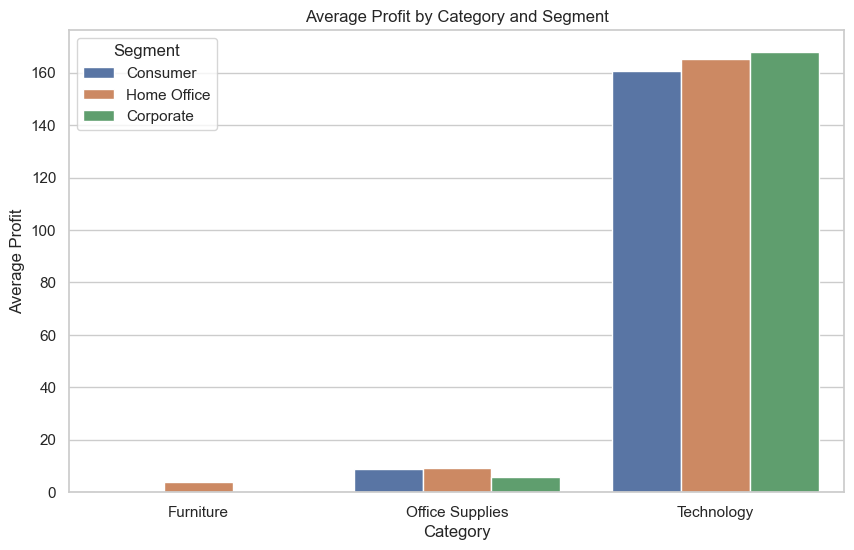

In [ ]:
# -----------------------------
# Visualization: Grouped Bar Chart
# -----------------------------

# Create a grouped bar chart using seaborn
sns.barplot(
    data=df,              # Data source: the full DataFrame
    
    # X-axis: product category (e.g., Electronics, Clothing, etc.)
    x="category",
    
    # Y-axis: numerical variable to aggregate (profit)
    y="profit",
    
    # hue creates sub-groups within each category
    # Each segment (e.g., Consumer, Corporate) gets its own color
    hue="segment",
    
    # estimator defines how values are aggregated within each group
    # Here: mean profit per (category, segment) combination
    estimator="mean",
    
    # Remove error bars (confidence intervals) for a cleaner, simpler chart
    errorbar=None
)

# Add descriptive title
plt.title("Average Profit by Category and Segment")

# Label axes
plt.xlabel("Category")
plt.ylabel("Average Profit")

# Show legend with a title for clarity
plt.legend(title="Segment")

# Render the plot
plt.show()

### Practice 1
Create:
1. a histogram for `sales`
2. a boxplot of `profit` by `category`
3. a line chart of monthly profit

Try on your own first.

In [ ]:
# Practice 1
# 1. Histogram of sales

# 2. Boxplot of profit by category

# 3. Monthly profit line chart

### Sample solution

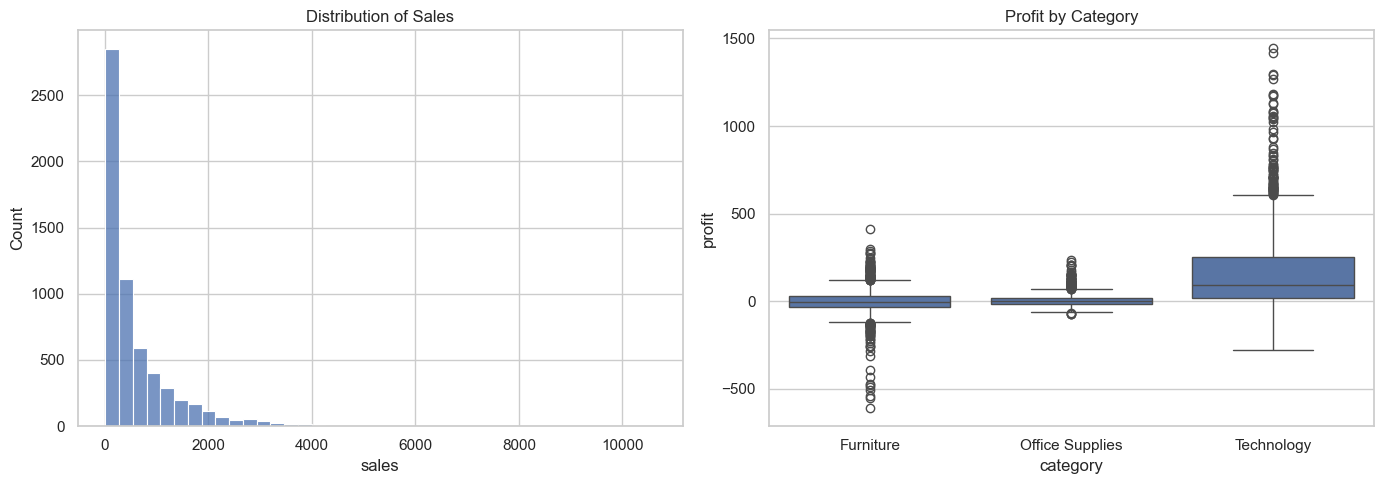

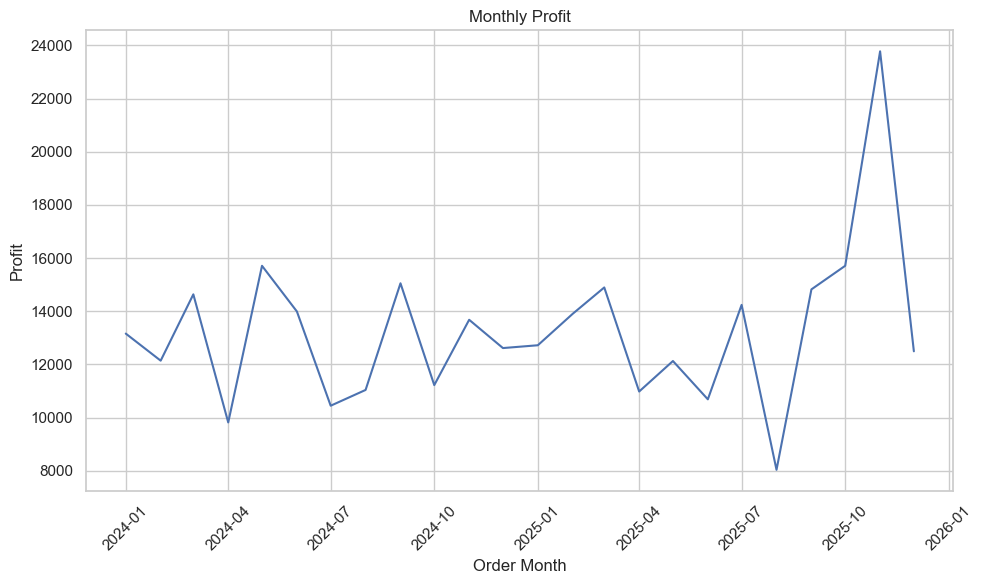

In [ ]:
# -----------------------------
# Subplots: One Figure, Multiple Charts
# -----------------------------

# Create a figure with 1 row and 2 columns (side-by-side plots)
# - fig: the entire canvas
# - axes: a list-like object containing each subplot (axes[0], axes[1])
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -----------------------------
# First Subplot (axes[0])
# -----------------------------

# Plot a histogram of sales distribution
# - Shows how sales values are spread (frequency of different ranges)
sns.histplot(
    data=df,
    x="sales",
    bins=40,          # number of bars (more bins = more detailed distribution)
    ax=axes[0]        # IMPORTANT: draw this plot on the first subplot
)

# Set title for the first subplot
axes[0].set_title("Distribution of Sales")


# -----------------------------
# Second Subplot (axes[1])
# -----------------------------

# Plot a boxplot of profit by category
# - Shows distribution (median, quartiles, outliers) for each category
sns.boxplot(
    data=df,
    x="category",
    y="profit",
    ax=axes[1]        # draw this plot on the second subplot
)

# Set title for the second subplot
axes[1].set_title("Profit by Category")


# Adjust spacing between subplots to avoid overlap
plt.tight_layout()

# Display both plots together in one figure
plt.show()



# -----------------------------
# Time Series: Monthly Profit
# -----------------------------

# Create a new DataFrame with profit aggregated by month
monthly_profit = (
    df
    # Convert order_date to month-level (all dates in same month become same value)
    .assign(order_month=df["order_date"].dt.to_period("M").dt.to_timestamp())
    
    # Group by month
    .groupby("order_month", as_index=False)["profit"]
    
    # Sum profit within each month
    .sum()
)

# -----------------------------
# Line Plot: Trend Over Time
# -----------------------------

# Plot monthly profit as a line chart
# - x-axis: time (month)
# - y-axis: total profit
plt.plot(monthly_profit["order_month"], monthly_profit["profit"])

# Add title and labels
plt.title("Monthly Profit")
plt.xlabel("Order Month")
plt.ylabel("Profit")

# Rotate x-axis labels for readability (dates can overlap)
plt.xticks(rotation=45)

# Adjust layout
plt.tight_layout()

# Display the plot
plt.show()

## Understand the data before plotting

A chart can be technically correct and still be analytically weak.

Examples:
- plotting missing values without noticing them,
- plotting a highly skewed variable and misreading it,
- plotting outliers without realizing they dominate the chart.

A good workflow is:

1. inspect missing values
2. inspect ranges and outliers
3. inspect distributions
4. decide whether cleaning or transformation is needed

In [ ]:
# Missing values
df.isna().sum().sort_values(ascending=False)

profit          18
discount        18
ship_mode       12
order_date       0
order_id         0
segment          0
state            0
region           0
category         0
quantity         0
sub_category     0
sales            0
customer_id      0
dtype: int64

### Discussion
- Which fields have missing values?
- Would missing values matter for every analysis?
- If `profit` is missing, should we drop the row for a profit analysis?

There is no universal answer.  
The key is: **notice the issue before you visualize**.

In [ ]:
# Basic range checks
df[numeric_cols].agg(["min", "max", "mean", "median"]).T

,min,max,mean,median
quantity,1.00,10.00,4.46,4.00
discount,0.00,0.55,0.14,0.12
sales,4.67,"10,636.00",604.38,299.06
profit,-610.00,"1,443.00",53.01,10.64


In [ ]:
# Identify some possible outliers
df.sort_values("sales", ascending=False).head(5)

,order_id,order_date,region,state,segment,category,sub_category,ship_mode,quantity,discount,sales,profit,customer_id
6000,ORD-2025-OUT0,2025-11-15,West,California,Corporate,Technology,Copiers,Same Day,10,0.05,"10,636.00","1,299.00",COUT0
6004,ORD-2025-OUT4,2025-11-19,West,California,Corporate,Technology,Copiers,Same Day,10,0.05,"10,589.00","1,289.00",COUT4
6003,ORD-2025-OUT3,2025-11-18,West,California,Corporate,Technology,Copiers,Same Day,10,0.05,"10,495.00","1,443.00",COUT3
6002,ORD-2025-OUT2,2025-11-17,West,California,Corporate,Technology,Copiers,Same Day,10,0.05,"10,493.00","1,134.00",COUT2
6006,ORD-2025-OUT6,2025-11-21,West,California,Corporate,Technology,Copiers,Same Day,10,0.05,"10,038.00","1,417.00",COUT6
6001,ORD-2025-OUT1,2025-11-16,West,California,Corporate,Technology,Copiers,Same Day,10,0.05,"9,798.00","1,172.00",COUT1
6005,ORD-2025-OUT5,2025-11-20,West,California,Corporate,Technology,Copiers,Same Day,10,0.05,"9,588.00","1,046.00",COUT5
6007,ORD-2025-OUT7,2025-11-22,West,California,Corporate,Technology,Copiers,Same Day,10,0.05,"9,057.00","1,123.00",COUT7
5254,ORD-2025-05254,2025-01-01,Central,Illinois,Home Office,Technology,Copiers,Second Class,8,0.09,"6,212.08","1,080.91",C11784
137,ORD-2024-00137,2024-07-25,South,Florida,Consumer,Technology,Copiers,Standard Class,7,0.06,"5,473.42","1,038.70",C11199


### Distribution analysis

Let's examine the distributions of sales, profit, quantity, and discount.

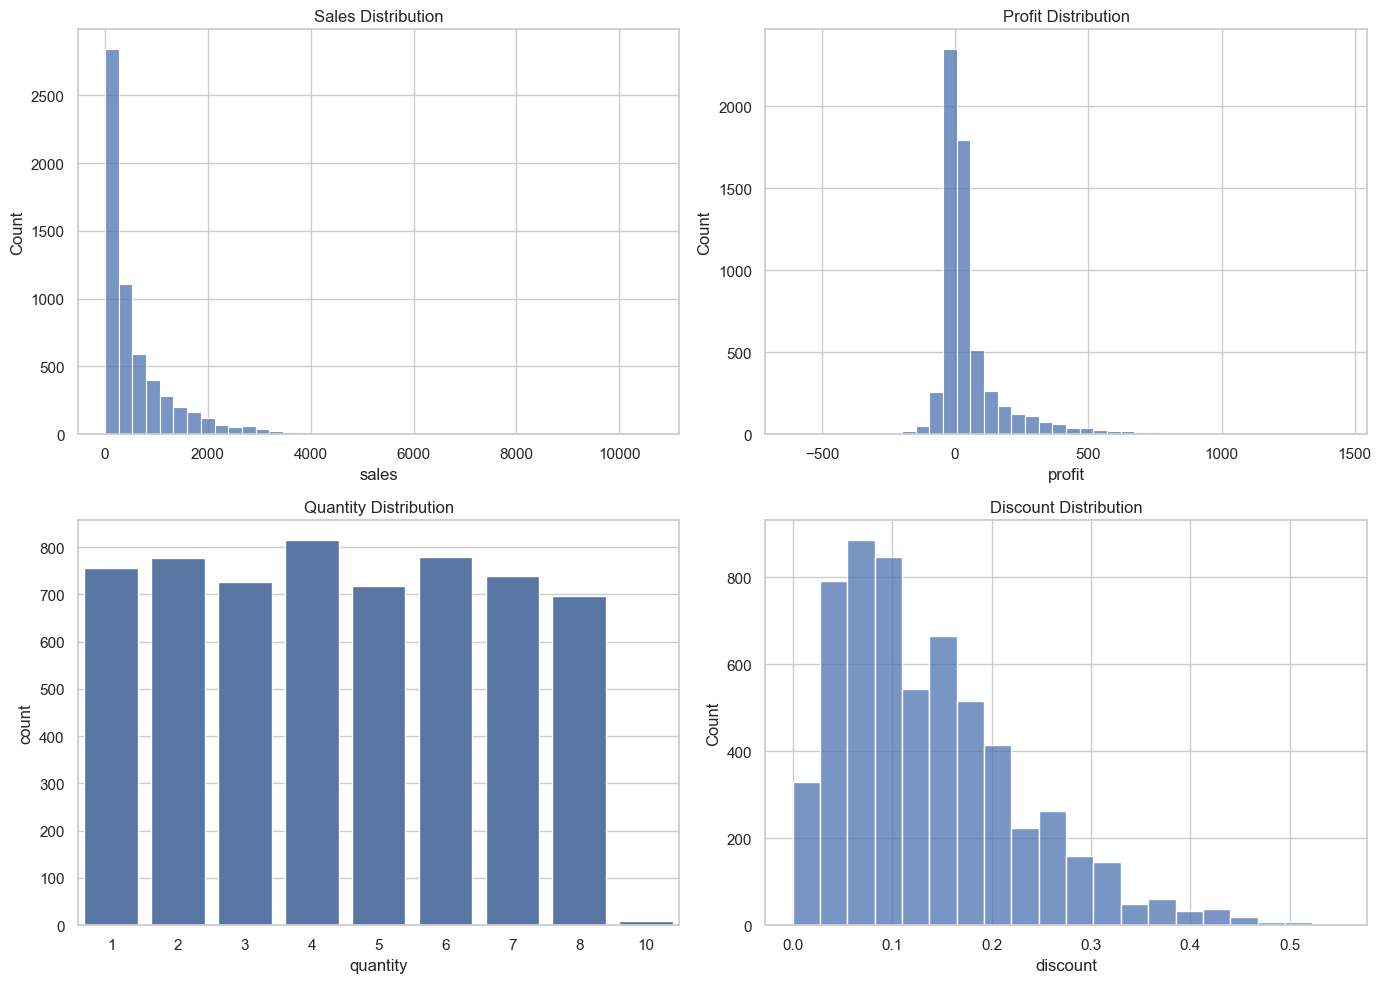

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(data=df, x="sales", bins=40, ax=axes[0, 0])
axes[0, 0].set_title("Sales Distribution")

sns.histplot(data=df, x="profit", bins=40, ax=axes[0, 1])
axes[0, 1].set_title("Profit Distribution")

sns.countplot(data=df, x="quantity", ax=axes[1, 0])
axes[1, 0].set_title("Quantity Distribution")

sns.histplot(data=df, x="discount", bins=20, ax=axes[1, 1])
axes[1, 1].set_title("Discount Distribution")

plt.tight_layout()
plt.show()

### Reflection questions
1. Is `sales` symmetric, or skewed?
2. Does `profit` include losses?
3. Are discounts concentrated at lower values or spread widely?
4. Could extreme sales values affect averages?

In [17]:
# Optional: compare mean vs median for skewed variables
df[["sales", "profit", "discount"]].agg(["mean", "median"]).T

,mean,median
sales,604.38,299.06
profit,53.01,10.64
discount,0.14,0.12


## Match business questions to chart types

This is one of the most important habits in visualization.

### Common question types

**1. Distribution**
- What does one variable look like?
- Good choices: histogram, KDE, boxplot

**2. Comparison**
- Which group is larger, higher, lower?
- Good choices: bar chart, boxplot

**3. Relationship**
- Are two variables connected?
- Good choices: scatter plot, regression plot

**4. Trend**
- How does a metric change over time?
- Good choices: line chart

**5. Composition / contribution**
- What share comes from each part?
- Good choices: stacked bar, percentage bar chart

### Exercise: choose the chart

For each question below, state the chart type you would use and why.

1. How are discounts distributed?
2. Which region has the highest total profit?
3. Is discount related to profit?
4. How did monthly sales change over time?
5. How does profit vary across categories?

In [18]:
chart_choices = {
    "1. How are discounts distributed?": "",
    "2. Which region has the highest total profit?": "",
    "3. Is discount related to profit?": "",
    "4. How did monthly sales change over time?": "",
    "5. How does profit vary across categories?": ""
}
chart_choices

{'1. How are discounts distributed?': '',
 '2. Which region has the highest total profit?': '',
 '3. Is discount related to profit?': '',
 '4. How did monthly sales change over time?': '',
 '5. How does profit vary across categories?': ''}

### Sample reasoning
- Distribution of discount → histogram
- Profit by region → bar chart
- Discount vs profit → scatter plot
- Monthly sales over time → line chart
- Profit across categories → boxplot or bar chart depending on the question

Notice the last one:
- if you want **average or total** by category → bar chart
- if you want **spread/variability** by category → boxplot

##  Core visualization patterns

This section builds the most useful chart patterns for real analytics work.

### Distribution: histogram and boxplot

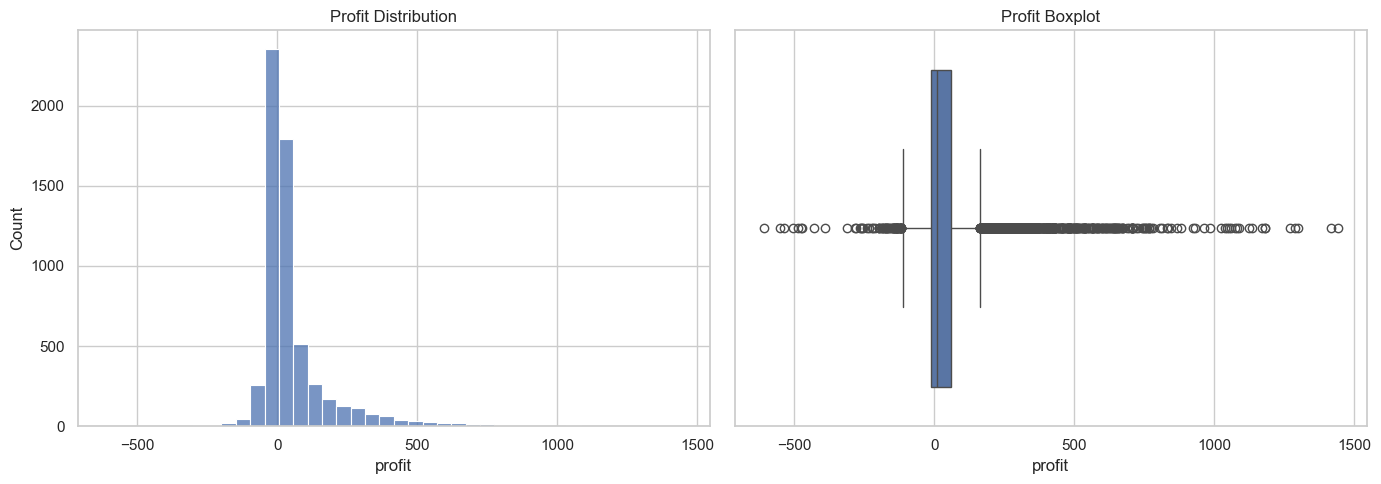

In [19]:
# Create a figure with 2 plots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))  # 1 row, 2 columns

# Histogram: shows distribution of profit values
sns.histplot(data=df, x="profit", bins=40, ax=axes[0])
axes[0].set_title("Profit Distribution")  # title for left plot

# Boxplot: shows spread and outliers of profit
sns.boxplot(data=df, x="profit", ax=axes[1])
axes[1].set_title("Profit Boxplot")  # title for right plot

# Adjust spacing between plots
plt.tight_layout()

# Display the plots
plt.show()

### Interpretation
- The histogram shows the overall shape.
- The boxplot quickly highlights spread and outliers.

These two are often a strong pair.

### Comparison: totals vs averages

In [20]:
# Group data by region and calculate summary statistics
region_summary = (
    df.groupby("region", as_index=False)  # group rows by region
      .agg(
          total_sales=("sales", "sum"),     # total sales per region
          avg_sales=("sales", "mean"),      # average sales per region
          total_profit=("profit", "sum"),   # total profit per region
          avg_profit=("profit", "mean")     # average profit per region
      )
)

region_summary  # display the result

,region,total_sales,avg_sales,total_profit,avg_profit
0,Central,"865,519.27",593.23,"65,309.54",44.79
1,East,"869,023.00",573.23,"72,866.77",48.16
2,South,"788,549.71",600.11,"66,217.71",50.66
3,West,"1,111,630.63",644.42,"113,475.99",66.05


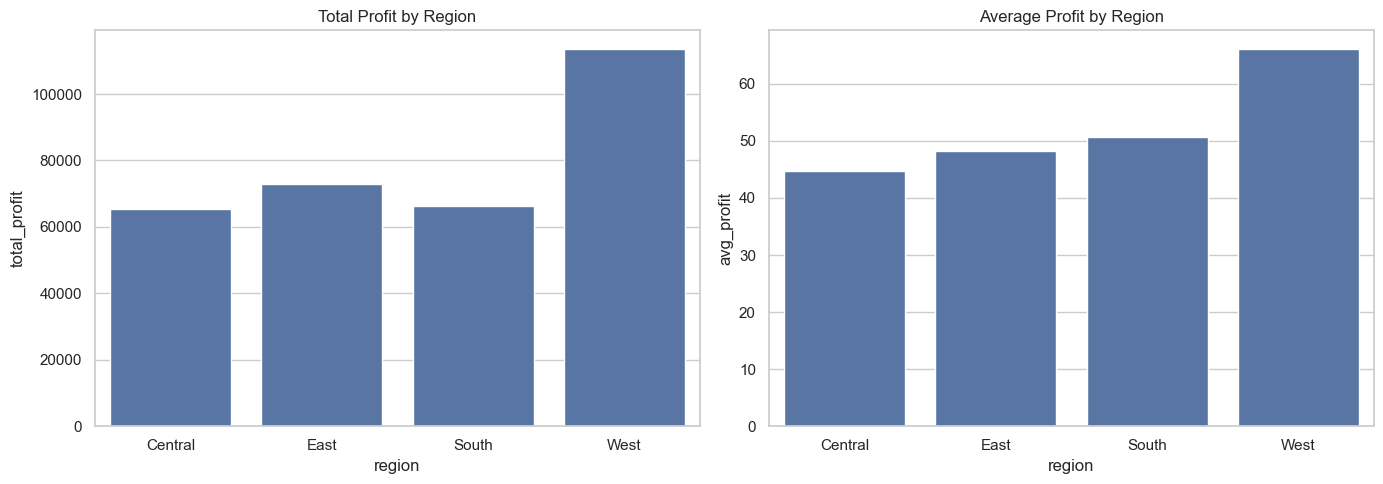

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=region_summary, x="region", y="total_profit", ax=axes[0])
axes[0].set_title("Total Profit by Region")

sns.barplot(data=region_summary, x="region", y="avg_profit", ax=axes[1])
axes[1].set_title("Average Profit by Region")

plt.tight_layout()
plt.show()

### Important lesson
A total and an average can tell different stories.

Always ask:
- Are you comparing total performance?
- Or typical performance per order?

### Relationship: scatter plot

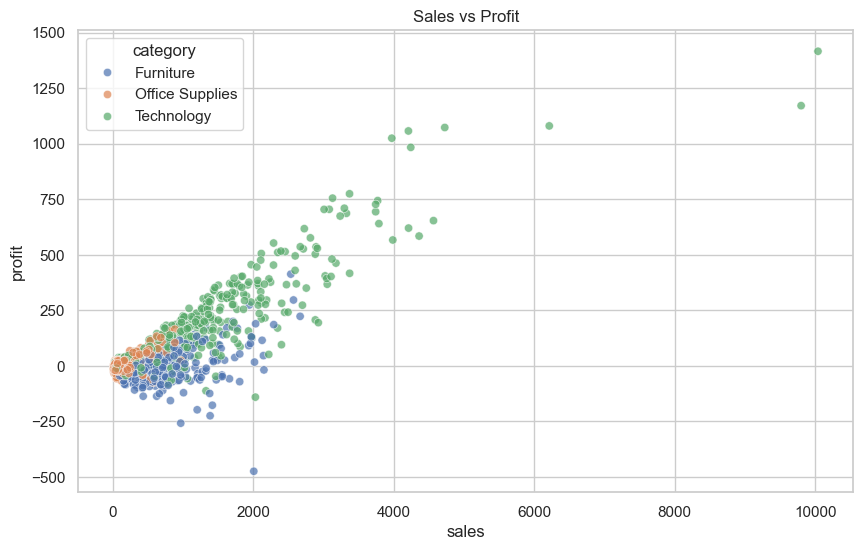

In [22]:
# Remove rows with missing values and take a random sample
sample_df = df.dropna(subset=["sales", "profit", "discount"]) \
              .sample(1500, random_state=42)  # fixed seed for reproducibility

# Scatter plot: relationship between sales and profit
sns.scatterplot(data=sample_df, x="sales", y="profit", hue="category", alpha=0.7)
# hue adds color by category, alpha controls transparency

plt.title("Sales vs Profit")  # chart title
plt.show()  # display plot

### Reflection
- Do higher sales always mean higher profit?
- Are some categories clustered differently?
- Do you notice any extreme points?

A scatter plot helps you see relationship, spread, and unusual cases.

### Trend: monthly sales and monthly profit

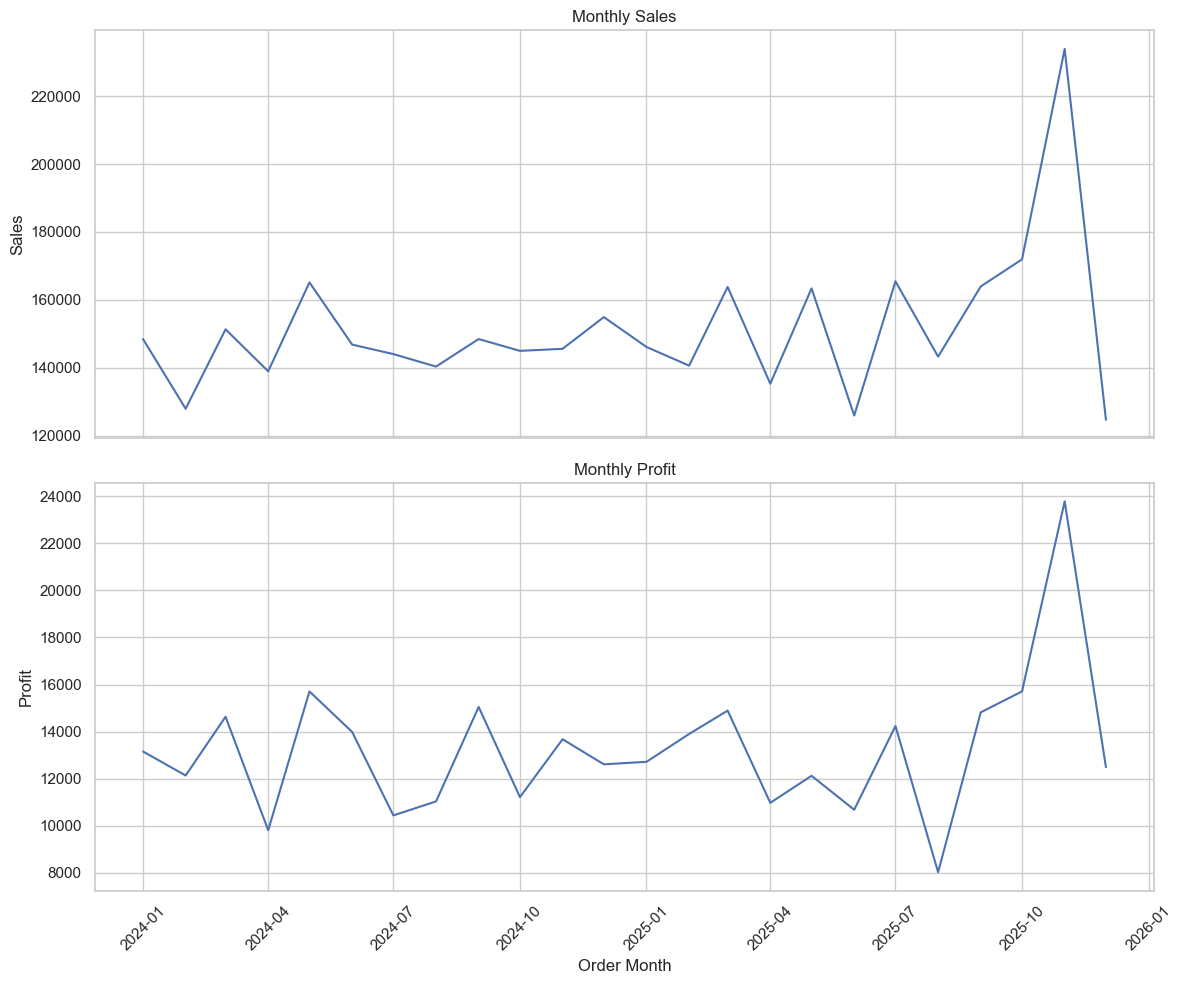

In [23]:
# Create monthly aggregated data
monthly = (
    df.assign(order_month=df["order_date"].dt.to_period("M").dt.to_timestamp())  # convert date to month
      .groupby("order_month", as_index=False)  # group by month
      .agg(
          total_sales=("sales", "sum"),    # total sales per month
          total_profit=("profit", "sum")   # total profit per month
      )
)

# Create 2 plots (one above the other), sharing the same x-axis
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Line plot for monthly sales
axes[0].plot(monthly["order_month"], monthly["total_sales"])
axes[0].set_title("Monthly Sales")   # title
axes[0].set_ylabel("Sales")          # y-axis label

# Line plot for monthly profit
axes[1].plot(monthly["order_month"], monthly["total_profit"])
axes[1].set_title("Monthly Profit")  # title
axes[1].set_ylabel("Profit")         # y-axis label
axes[1].set_xlabel("Order Month")    # x-axis label

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Adjust layout to avoid overlap
plt.tight_layout()

# Display the plots
plt.show()

### Reflection
- Are sales and profit moving together?
- Do you see seasonality?
- Are there months where sales are high but profit is weak?

## Guided mini-case: a retail manager asks for help

You are a junior data scientist supporting a retail leadership team.

The team asks three questions:

1. Which categories and regions drive business performance?
2. Is discounting likely hurting profitability?
3. What should we investigate next?

Your job:
- explore the data,
- build useful charts,
- and write short analytical observations.

### Category and region performance

In [24]:
# Group data by region and category, then calculate summary metrics
category_region = (
    df.groupby(["region", "category"], as_index=False)  # group by two columns
      .agg(
          total_sales=("sales", "sum"),     # total sales for each group
          total_profit=("profit", "sum"),   # total profit for each group
          avg_discount=("discount", "mean") # average discount for each group
      )
)

category_region.head()  # show first 5 rows

,region,category,total_sales,total_profit,avg_discount
0,Central,Furniture,"275,892.62","-4,439.83",0.18
1,Central,Office Supplies,"112,465.54","4,521.94",0.12
2,Central,Technology,"477,161.11","65,227.43",0.13
3,East,Furniture,"278,088.74","2,102.65",0.17
4,East,Office Supplies,"117,988.32","5,395.03",0.13


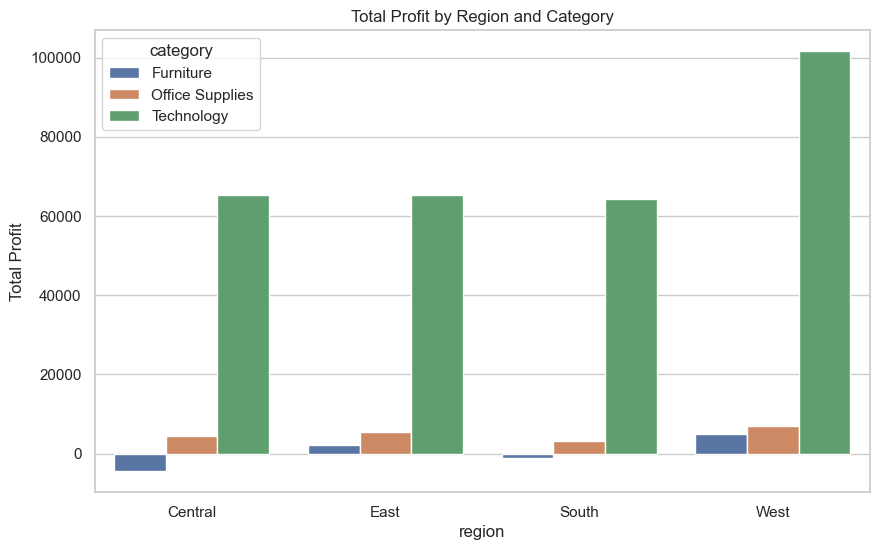

In [25]:
sns.barplot(data=category_region, x="region", y="total_profit", hue="category", errorbar=None)
plt.title("Total Profit by Region and Category")
plt.ylabel("Total Profit")
plt.show()

### Discount and profit

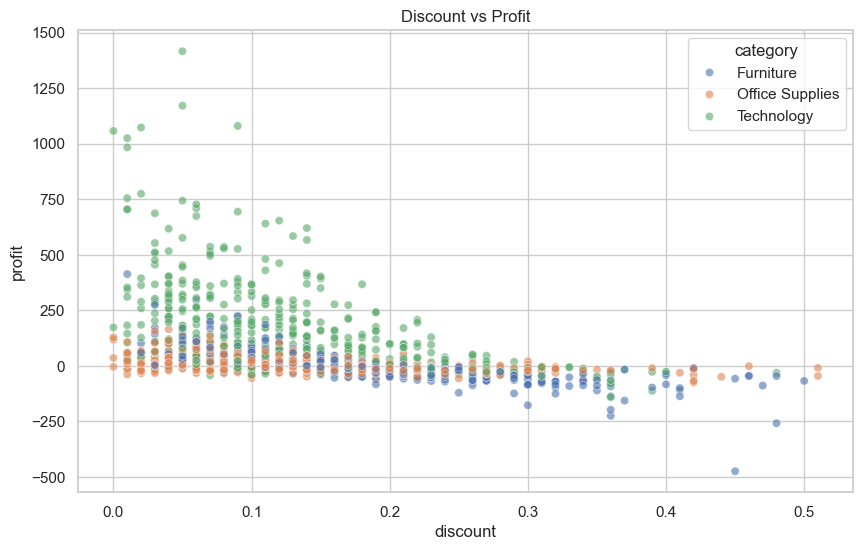

In [26]:
# Scatter plot with a sampled dataset (remove missing values first)
sns.scatterplot(
    data=df.dropna(subset=["discount", "profit"])  # remove rows with missing values
           .sample(1500, random_state=42),        # take random sample for speed
    x="discount",    # x-axis: discount
    y="profit",      # y-axis: profit
    hue="category",  # color points by category
    alpha=0.6        # transparency (helps with overlapping points)
)

plt.title("Discount vs Profit")  # chart title
plt.show()  # display plot

In [27]:
# Select discount and profit columns, then compute correlation
df[["discount", "profit"]].corr()  # shows how strongly they are related

,discount,profit
discount,1.00,-0.39
profit,-0.39,1.00


### Note
Correlation does not prove causation.  
But it can suggest a pattern worth investigating.

A useful analyst response might be:

> “Higher discount levels appear associated with lower profit, especially in some categories. We should examine whether aggressive discounting in specific product groups is driving losses.”

### Investigate a loss-making area

In [ ]:
# Group data by sub-category and calculate key metrics
loss_by_subcat = (
    df.groupby("sub_category", as_index=False)  # group by sub-category
      .agg(
          total_profit=("profit", "sum"),     # total profit per sub-category
          avg_discount=("discount", "mean"),  # average discount
          total_sales=("sales", "sum")        # total sales
      )
      .sort_values("total_profit")  # sort by profit (lowest first)
)

loss_by_subcat.head(5)  # show top 5 lowest-profit sub-categories

,sub_category,total_profit,avg_discount,total_sales
8,Paper,"-5,810.77",0.13,"38,598.32"
6,Furnishings,"-2,510.78",0.17,"106,297.35"
11,Tables,"-1,630.81",0.18,"482,263.14"
2,Binders,"-1,435.97",0.13,"71,571.22"
3,Bookcases,"1,676.10",0.17,"233,558.96"
0,Accessories,"2,389.42",0.13,"57,600.08"
4,Chairs,"3,990.66",0.17,"259,424.89"
10,Storage,"7,295.03",0.12,"124,585.34"
1,Appliances,"19,911.77",0.13,"226,596.94"
9,Phones,"57,791.97",0.12,"408,448.16"


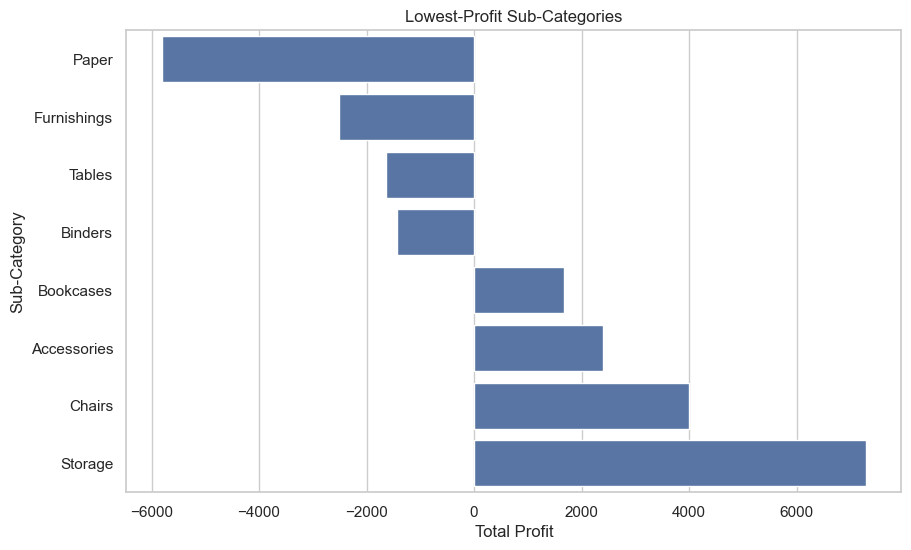

In [29]:
sns.barplot(data=loss_by_subcat.head(8), x="total_profit", y="sub_category")
plt.title("Lowest-Profit Sub-Categories")
plt.xlabel("Total Profit")
plt.ylabel("Sub-Category")
plt.show()

### Mini-case task

Write 3 short observations:
1. one about categories or regions,
2. one about discounting,
3. one about a sub-category or shipping issue worth deeper analysis.

In [30]:
observations = [
    "1.",
    "2.",
    "3."
]
observations

['1.', '2.', '3.']

## Visualization best practices for beginners

### Do
- Start with a question
- Label clearly
- Keep charts simple
- Compare totals vs averages carefully
- Inspect the data before plotting
- Use color intentionally

### Don't
- Add unnecessary clutter
- Use 3D charts
- Use a pie chart for everything
- Truncate axes carelessly
- Treat a chart as insight by itself

### Example: a clearer chart

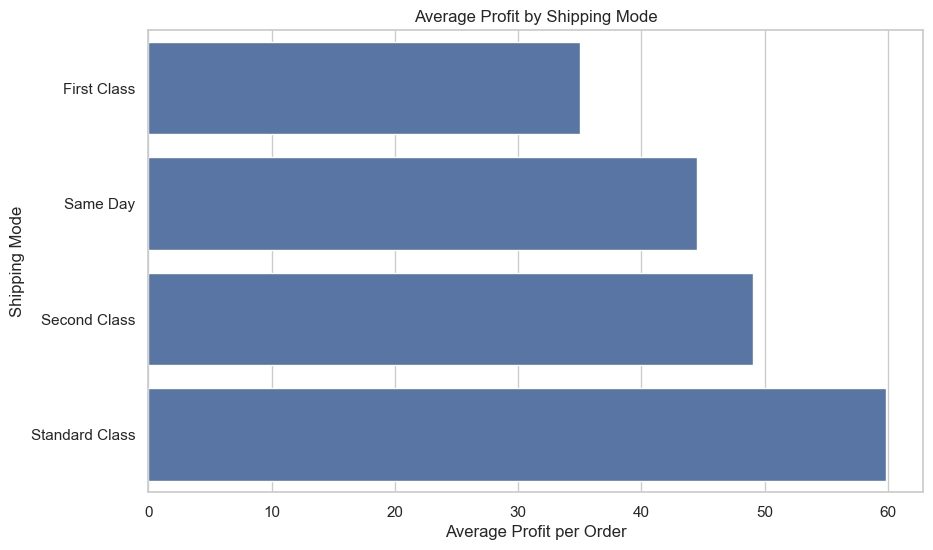

In [32]:
profit_by_ship = (
    df.groupby("ship_mode", as_index=False)
      .agg(avg_profit=("profit", "mean"))
      .sort_values("avg_profit")
)

sns.barplot(data=profit_by_ship, x="avg_profit", y="ship_mode")
plt.title("Average Profit by Shipping Mode")
plt.xlabel("Average Profit per Order")
plt.ylabel("Shipping Mode")
plt.show()

### Why this is clear
- one message,
- readable labels,
- no distracting decoration,
- easy comparison.